In [325]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from datetime import datetime
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv(r"C:\Programming\Machine Learning\Used Car Price Intelligence\Used Car Arbitrage\data\raw\raw_car_listings.csv")
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual


In [3]:
df.shape

(4258, 5)

In [4]:
def clean_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().replace("₹",'').replace(',','').strip()
    if 'crore' in val or 'cr' in val:
        num = re.findall(r'[\d\.]+',val)
        return float(num[0])*10000000 if num else np.nan
    elif 'lakh' in val or 'lac' in val:
            num = re.findall(r'[\d\.]+',val)
            return float(num[0])*100000 if num else np.nan
    else:
        num = re.findall(r'[\d\.]+',val)
        if num:
            n = float(num[0])
            return n
        return np.nan

In [5]:
def clean_kilometers(val):
    if pd.isna(val):
        return np.nan

    clean_val = str(val).lower().replace('km','').replace(',','').strip()
    try:
        return float(clean_val)
    except ValueError:
        return np.nan

In [6]:
df['clean_price'] = df['Price'].apply(clean_price)

In [7]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0


In [8]:
df['clean_kms'] = df['Kilometers'].apply(clean_kilometers)

In [9]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0


In [10]:
df['Transmission'].value_counts()['Missing Transmission']

np.int64(907)

In [11]:
df['updated_transmission'] = df['Transmission'].replace("Missing Transmission",np.nan)

In [12]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual


In [13]:
df['updated_transmission'].value_counts()

updated_transmission
Manual    3351
Name: count, dtype: int64

In [14]:
df['updated_transmission'].nunique(dropna=False)

2

sirf Nan or manual transmission present hai data mai 3351(manual)+907(Nan) = 4258. Automatic hai hi nahi

In [15]:
df['Year'] = df['Title'].str.extract(r'^(\d{4})')

In [16]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020


In [17]:
df['Brand'] = df['Title'].str.extract(r'^\d{4}\s+(\w+)')

In [18]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault


In [19]:
df['Model'] = df['Title'].str.extract(r'^\d{4}\s+\w+\s+(.+)')

In [20]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata,NEXON
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault,Kwid


In [21]:
df = df.drop(['Title','Price','Kilometers','Transmission'],axis = 1)

In [22]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,Petrol,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,CNG,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,Petrol,520000.0,50912.0,Manual,2020,Tata,NEXON
4,Petrol,250000.0,68431.0,Manual,2020,Renault,Kwid


In [23]:
df['clean_price'].describe()

count    4.258000e+03
mean     4.966101e+05
std      3.799964e+05
min      4.800000e+04
25%      2.322500e+05
50%      4.000000e+05
75%      6.500000e+05
max      5.005000e+06
Name: clean_price, dtype: float64

In [24]:
df['Brand'] = df['Brand'].str.lower()
df['Model'] = df['Model'].str.lower()

In [25]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,hyundai,eon
1,Petrol,239000.0,42678.0,Manual,2017,maruti,wagon r 1.0
2,CNG,164000.0,60214.0,Manual,2018,datsun,redi go
3,Petrol,520000.0,50912.0,Manual,2020,tata,nexon
4,Petrol,250000.0,68431.0,Manual,2020,renault,kwid


In [26]:
df['Fuel_Type'].value_counts(dropna=False)

Fuel_Type
Petrol      2891
CNG          884
Diesel       458
Hybrid        14
Electric      11
Name: count, dtype: int64

In [27]:
(df.isna().mean()*100).round(2)

Fuel_Type                0.0
clean_price              0.0
clean_kms                0.0
updated_transmission    21.3
Year                     0.0
Brand                    0.0
Model                    0.0
dtype: float64

In [28]:
df['Brand'].nunique()

24

<Axes: xlabel='clean_price', ylabel='Count'>

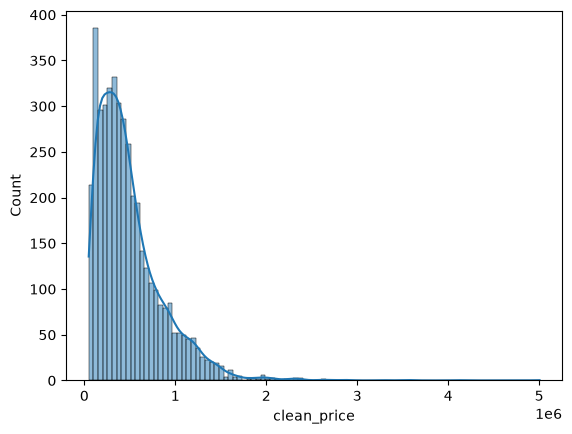

In [29]:
sns.histplot(data =df,x='clean_price',kde=True)

In [30]:
df['clean_price'].skew()

np.float64(2.300287519586333)

<Axes: xlabel='Fuel_Type', ylabel='clean_price'>

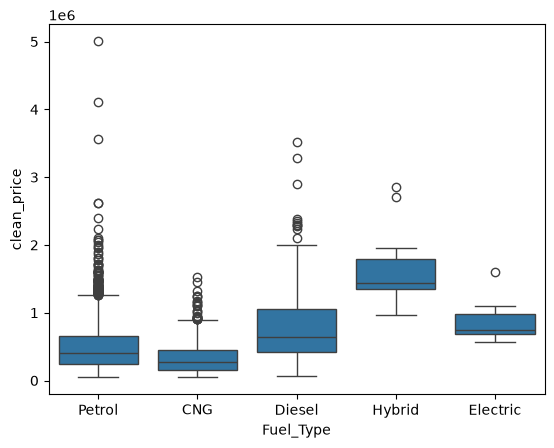

In [31]:
sns.boxplot(data = df, x='Fuel_Type',y='clean_price')

<Axes: xlabel='clean_kms', ylabel='clean_price'>

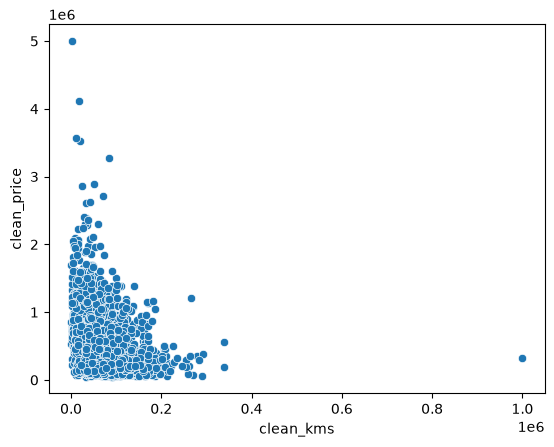

In [32]:
sns.scatterplot(data=df,x='clean_kms',y='clean_price')

In [33]:
df[df['clean_kms']>300000]

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
552,CNG,189000.0,338648.0,Manual,2016,maruti,wagon r 1.0
2283,Petrol,330000.0,999245.0,NaN,2017,maruti,baleno
4106,Diesel,567000.0,339522.0,Manual,2019,hyundai,venue


In [34]:
np.log1p(df['clean_price']).skew()

np.float64(-0.21100238410791378)

<Axes: xlabel='clean_price', ylabel='Count'>

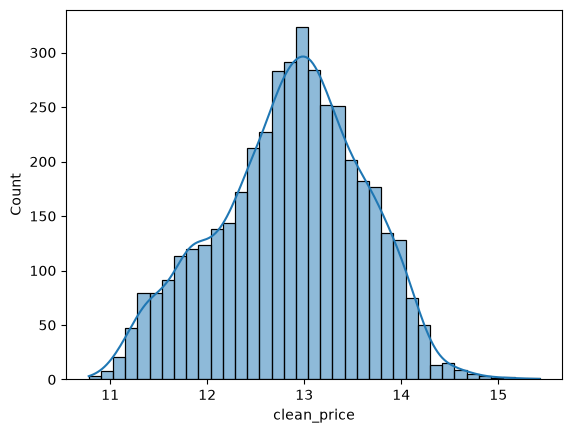

In [35]:
sns.histplot(data=df,x=np.log1p(df['clean_price']),kde=True)

In [36]:
df.query("clean_kms > 300000")

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
552,CNG,189000.0,338648.0,Manual,2016,maruti,wagon r 1.0
2283,Petrol,330000.0,999245.0,NaN,2017,maruti,baleno
4106,Diesel,567000.0,339522.0,Manual,2019,hyundai,venue


In [37]:
df = df.drop(index=[552,2283,4106])

In [38]:
df.query("clean_kms>300000")

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model


In [39]:
current_year = datetime.now().year
df['car_age'] = current_year - df['Year'].astype(int)
df['km_per_year'] = df['clean_kms'] / np.maximum(1,df['car_age'])
df['brand_model'] = df['Brand'] + '_' + df['Model']

In [40]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model,car_age,km_per_year,brand_model
0,Petrol,172000.0,43518.0,Manual,2015,hyundai,eon,11,3956.181818,hyundai_eon
1,Petrol,239000.0,42678.0,Manual,2017,maruti,wagon r 1.0,9,4742.000000,maruti_wagon r 1.0
2,CNG,164000.0,60214.0,Manual,2018,datsun,redi go,8,7526.750000,datsun_redi go
3,Petrol,520000.0,50912.0,Manual,2020,tata,nexon,6,8485.333333,tata_nexon
4,Petrol,250000.0,68431.0,Manual,2020,renault,kwid,6,11405.166667,renault_kwid


In [41]:
df = df.drop(['Year','Brand','Model'],axis = 1)

In [42]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,car_age,km_per_year,brand_model
0,Petrol,172000.0,43518.0,Manual,11,3956.181818,hyundai_eon
1,Petrol,239000.0,42678.0,Manual,9,4742.000000,maruti_wagon r 1.0
2,CNG,164000.0,60214.0,Manual,8,7526.750000,datsun_redi go
3,Petrol,520000.0,50912.0,Manual,6,8485.333333,tata_nexon
4,Petrol,250000.0,68431.0,Manual,6,11405.166667,renault_kwid


In [43]:
df.to_csv(r"C:\Programming\Machine Learning\Used Car Price Intelligence\Used Car Arbitrage\data\Processed\clean_car_listing.csv",index=False)

In [44]:
X = df[["brand_model","Fuel_Type","km_per_year","car_age","clean_kms"]]
y = np.log1p(df['clean_price'])

In [45]:
X.shape

(4255, 5)

In [46]:
y.shape

(4255,)

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
X_train.shape

(3404, 5)

In [49]:
y_train.shape

(3404,)

In [50]:
num_cols = ['clean_kms','car_age','km_per_year']
ohe_cols = ['Fuel_Type']
target_cols = ['brand_model']

In [51]:
preprocessor = ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols),
    ('ohe',OneHotEncoder(),ohe_cols),
    ('target',TargetEncoder(),target_cols)
])

In [52]:
lr_pipe =Pipeline([('prep',preprocessor),('model',LinearRegression())])

In [53]:
lr_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['brand_model','Fuel_Type','km_per_year','car_age','clean_kms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [54]:
y_train_pred=lr_pipe.predict(X_train)

In [55]:
y_train_pred

array([11.58260398, 11.70262709, 13.47599626, ..., 11.45677305,
       13.436113  , 12.92342804], shape=(3404,))

In [56]:
y_test_pred = lr_pipe.predict(X_test)

In [57]:
y_test_pred

array([12.18297515, 11.55230604, 14.65186061, 13.07036519, 11.73992772,
       12.70424947, 11.55827301, 11.57446544, 13.23139569, 11.90859395,
       13.38747239, 11.4657258 , 12.71146672, 12.52906356, 13.49717092,
       12.56481671, 12.2148938 , 12.73435169, 12.70383399, 13.35284269,
       12.89529595, 11.704794  , 12.5017413 , 12.5120593 , 11.5474174 ,
       12.79448727, 12.51666092, 12.93811332, 13.08502737, 12.56241376,
       12.01596867, 12.41482529, 13.37721807, 13.60900004, 12.14666366,
       12.11263567, 11.90172974, 13.00160331, 11.99225625, 12.35439349,
       12.78895781, 12.63452854, 13.1759218 , 12.52334656, 12.4680399 ,
       13.59912524, 11.97408971, 12.69963437, 11.89059032, 12.76830234,
       13.11809119, 12.0564527 , 13.98273495, 13.86063704, 11.40859321,
       12.70968349, 13.0774597 , 11.96509912, 12.67761667, 12.0426627 ,
       12.59215425, 11.94533559, 13.15198295, 12.74148315, 11.64240237,
       11.56178718, 12.76275874, 12.93827032, 13.904704  , 11.82

In [58]:
y_test_pred.shape

(851,)

In [59]:
n = X.shape[0]
p = X.shape[1]
print("N: ",n,' P: ',p)

N:  4255  P:  5


In [60]:
r2_train = r2_score(y_train,y_train_pred)

In [61]:
r2_train

0.8905655513457637

In [62]:
adj_r2_train = 1-((1-r2_train)*(n-1)/(n-p-1))

In [63]:
adj_r2_train

0.8904367746351797

In [64]:
r2_test = r2_score(y_test,y_test_pred)

In [65]:
r2_test

0.8629252976257689

In [66]:
adj_r2_test = 1-((1-r2_test)*(n-1)/(n-p-1))

In [67]:
adj_r2_test

0.8627639953165499

In [68]:
rmse_train = root_mean_squared_error(y_train,y_train_pred)

In [69]:
rmse_train

0.250110117488319

In [70]:
rmse_test = root_mean_squared_error(y_test,y_test_pred)

In [71]:
rmse_test

0.2726391278665092

In [72]:
mae_train = mean_absolute_error(y_train,y_train_pred)

In [73]:
mae_train

0.1945586301278286

In [74]:
mae_test = mean_absolute_error(y_test,y_test_pred)

In [75]:
mae_test

0.20149134908177316

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [76]:
ridge_pipe = Pipeline([('prep',preprocessor),('model',Ridge())])

In [77]:
ridge_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [78]:
param_grid = {'model__alpha':[0.01,0.1,1.0,5.0,10.0,20.0,50.0,100.0]}

In [79]:
grid_ridge = GridSearchCV(ridge_pipe,param_grid,cv = 5, scoring='r2')

In [80]:
grid_ridge

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [81]:
grid_ridge.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [82]:
grid_ridge.best_params_

{'model__alpha': 0.1}

In [83]:
grid_ridge.best_score_

np.float64(0.8675563261448385)

In [84]:
y_train_pred_ridge = grid_ridge.predict(X_train)

In [85]:
y_test_pred_ridge = grid_ridge.predict(X_test)

In [86]:
r2_train_ridge = r2_score(y_train,y_train_pred_ridge)

In [87]:
r2_train_ridge

0.8906089606613448

In [88]:
r2_test_ridge = r2_score(y_test,y_test_pred_ridge)

In [89]:
r2_test_ridge

0.8628469503384985

In [90]:
adj_r2_train_ridge = 1-((1-r2_train_ridge)*(n-1)/(n-p-1))

In [91]:
adj_r2_train_ridge

0.8904802350325631

In [92]:
adj_r2_test_ridge = 1-((1-r2_test_ridge)*(n-1)/(n-p-1))

In [93]:
adj_r2_test_ridge

0.8626855558343074

In [94]:
rmse_train_ridge = root_mean_squared_error(y_train,y_train_pred_ridge)

In [95]:
rmse_train_ridge

0.2500605070318385

In [96]:
rmse_test_ridge = root_mean_squared_error(y_test,y_test_pred_ridge)

In [97]:
rmse_test_ridge

0.2727170324117434

In [98]:
mae_train_ridge = mean_absolute_error(y_train,y_train_pred_ridge)

In [99]:
mae_train_ridge

0.19457063718672996

In [100]:
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

In [101]:
mae_test_ridge

0.2015127098569418

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [102]:
lasso_pipe = Pipeline([('prep',preprocessor),('model',Lasso(random_state=42,max_iter=1000))])

In [103]:
lasso_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [104]:
param_grid_Lasso = {'model__alpha':[0.0001,0.0005,0.001,0.005,0.01,0.05,0.1,1.0,5.0,10.0]}

In [105]:
grid_lasso = GridSearchCV(lasso_pipe,param_grid_Lasso,cv = 5, scoring='r2')

In [106]:
grid_lasso

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [107]:
grid_lasso = grid_lasso.fit(X_train,y_train)

In [108]:
grid_lasso

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [109]:
grid_lasso.best_params_

{'model__alpha': 0.0001}

In [110]:
grid_lasso.best_score_

np.float64(0.8671239853374673)

In [111]:
y_train_pred_lasso = grid_lasso.predict(X_train)

In [112]:
y_train_pred_lasso

array([11.58488347, 11.70632604, 13.4842928 , ..., 11.45887577,
       13.43634988, 12.92230973], shape=(3404,))

In [113]:
y_test_pred_lasso = grid_lasso.predict(X_test)

In [114]:
y_test_pred_lasso

array([12.18455318, 11.55554712, 14.66315594, 13.07216142, 11.74325669,
       12.70337085, 11.56256105, 11.57513903, 13.24108587, 11.91407298,
       13.3864401 , 11.46959509, 12.71262016, 12.5215733 , 13.4991358 ,
       12.56026277, 12.2165521 , 12.7325063 , 12.69770907, 13.35341527,
       12.89517179, 11.70578029, 12.49768027, 12.5100044 , 11.54980072,
       12.80519612, 12.51538203, 12.94006268, 13.09446376, 12.56624778,
       12.01535957, 12.41193289, 13.37382816, 13.60476335, 12.15058339,
       12.11239131, 11.90515725, 13.00793969, 11.99727025, 12.35372741,
       12.78629748, 12.62926019, 13.1800089 , 12.52064857, 12.46860646,
       13.60178064, 11.97771341, 12.7017738 , 11.89364346, 12.76711473,
       13.12156601, 12.0593988 , 13.98219671, 13.8615947 , 11.41213222,
       12.70498255, 13.07684161, 11.96751139, 12.67412786, 12.04385681,
       12.58799912, 11.94821377, 13.1608636 , 12.74012626, 11.64361143,
       11.55175641, 12.76130846, 12.9365662 , 13.90396136, 11.82

In [115]:
r2_train_lasso = r2_score(y_train,y_train_pred_lasso)

In [116]:
r2_train_lasso

0.8903656193318923

In [117]:
r2_test_lasso = r2_score(y_test,y_test_pred_lasso)

In [118]:
r2_test_lasso

0.8631838825794206

In [119]:
adj_r2_train_lasso = 1-((1-r2_train_lasso)*(n-1)/(n-p-1))

In [120]:
adj_r2_train_lasso

0.8902366073518169

In [121]:
adj_r2_test_lasso = 1-((1-r2_test_lasso)*(n-1)/(n-p-1))

In [122]:
adj_r2_test_lasso

0.8630228845593917

In [123]:
rmse_train_lasso = root_mean_squared_error(y_train,y_train_pred_lasso)

In [124]:
rmse_train_lasso

0.2503384834264677

In [125]:
rmse_test_lasso = root_mean_squared_error(y_test,y_test_pred_lasso)

In [126]:
rmse_test_lasso

0.2723818460510928

In [127]:
mae_train_lasso = mean_absolute_error(y_train,y_train_pred_lasso)

In [128]:
mae_train_lasso

0.19472633498246597

In [129]:
mae_test_lasso = mean_absolute_error(y_test,y_test_pred_lasso)

In [130]:
mae_test_lasso

0.20151076115367977

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [131]:
elastic_pipe = Pipeline([("prep",preprocessor),("model",ElasticNet(random_state=42,max_iter=2000))])

In [132]:
elastic_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [133]:
parameter_grid_elastic = {
    'model__alpha':[0.0001,0.0005,0.001,0.01,0.1,1.0],
    'model__l1_ratio':[0.1,0.3,0.5,0.7,0.9]
}

In [134]:
grid_elastic = GridSearchCV(elastic_pipe,parameter_grid_elastic,cv = 5,scoring='r2')

In [135]:
grid_elastic

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...], 'model__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [136]:
grid_elastic.fit(X_train,y_train)

c:\Users\Lenovo\anaconda3\envs\car_arbitrage\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.681155e-01, tolerance: 1.571e-01
  model = cd_fast.enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...], 'model__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [137]:
grid_elastic.best_score_

np.float64(0.8675930402961567)

In [138]:
grid_elastic.best_params_

{'model__alpha': 0.0001, 'model__l1_ratio': 0.9}

In [139]:
y_train_pred_elastic = grid_elastic.predict(X_train)
y_test_pred_elastic = grid_elastic.predict(X_test)

In [140]:
y_test_pred_elastic

array([12.18214049, 11.55407577, 14.65624109, 13.06958842, 11.74105558,
       12.70252915, 11.56072887, 11.57525675, 13.23428489, 11.91358965,
       13.38662587, 11.46824438, 12.71211687, 12.5263609 , 13.49498145,
       12.56158305, 12.21422788, 12.7342603 , 12.69992287, 13.35024719,
       12.89535278, 11.70756173, 12.50276823, 12.51115487, 11.548625  ,
       12.79854351, 12.51483106, 12.94015277, 13.0891242 , 12.56547034,
       12.01590786, 12.41493959, 13.37397008, 13.60609015, 12.14916105,
       12.11103522, 11.90455838, 13.0006058 , 11.99653398, 12.35396928,
       12.78769912, 12.63100745, 13.17449641, 12.52203401, 12.46995814,
       13.59860202, 11.97608845, 12.7034099 , 11.89391364, 12.7665757 ,
       13.11881931, 12.05875785, 13.98143549, 13.85917867, 11.41016719,
       12.70755482, 13.07544516, 11.96626271, 12.67468574, 12.04257907,
       12.58929172, 11.94611675, 13.15498239, 12.7420692 , 11.64249182,
       11.55786858, 12.75976545, 12.93676807, 13.90161769, 11.82

In [141]:
y_test_pred_elastic

array([12.18214049, 11.55407577, 14.65624109, 13.06958842, 11.74105558,
       12.70252915, 11.56072887, 11.57525675, 13.23428489, 11.91358965,
       13.38662587, 11.46824438, 12.71211687, 12.5263609 , 13.49498145,
       12.56158305, 12.21422788, 12.7342603 , 12.69992287, 13.35024719,
       12.89535278, 11.70756173, 12.50276823, 12.51115487, 11.548625  ,
       12.79854351, 12.51483106, 12.94015277, 13.0891242 , 12.56547034,
       12.01590786, 12.41493959, 13.37397008, 13.60609015, 12.14916105,
       12.11103522, 11.90455838, 13.0006058 , 11.99653398, 12.35396928,
       12.78769912, 12.63100745, 13.17449641, 12.52203401, 12.46995814,
       13.59860202, 11.97608845, 12.7034099 , 11.89391364, 12.7665757 ,
       13.11881931, 12.05875785, 13.98143549, 13.85917867, 11.41016719,
       12.70755482, 13.07544516, 11.96626271, 12.67468574, 12.04257907,
       12.58929172, 11.94611675, 13.15498239, 12.7420692 , 11.64249182,
       11.55786858, 12.75976545, 12.93676807, 13.90161769, 11.82

In [142]:
r2_train_elastic = r2_score(y_train, y_train_pred_elastic)

In [143]:
r2_train_elastic

0.8905085484487582

In [144]:
r2_test_elastic = r2_score(y_test, y_test_pred_elastic)

In [145]:
r2_test_elastic

0.8629841650468904

In [146]:
rmse_test_elastic = root_mean_squared_error(y_test,y_test_pred_elastic)

In [147]:
rmse_test_elastic

0.2725805784566335

In [148]:
mae_test_elastic = mean_absolute_error(y_test, y_test_pred_elastic)

In [149]:
mae_test_elastic

0.20144316297066256

### Model 5: K-Nearest Neighbors (KNN)

In [151]:
knn_pipe = Pipeline([('prep', preprocessor), ('model', KNeighborsRegressor())])

In [152]:
knn_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [153]:
param_grid_knn = {'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21], 'model__weights': ['uniform', 'distance'], 'model__p': [1, 2]}

In [154]:
grid_knn = GridSearchCV(knn_pipe, param_grid_knn, cv=5, scoring='r2', n_jobs=-1)

In [155]:
grid_knn

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [156]:
grid_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [157]:
grid_knn.best_params_

{'model__n_neighbors': 15, 'model__p': 2, 'model__weights': 'uniform'}

In [158]:
grid_knn.best_score_

np.float64(0.8622176216313726)

In [159]:
y_train_pred_knn = grid_knn.predict(X_train)

In [160]:
y_train_pred_knn

array([11.51324134, 11.5956168 , 13.4456371 , ..., 11.3974324 ,
       13.36006928, 12.93353097], shape=(3404,))

In [161]:
y_test_pred_knn = grid_knn.predict(X_test)

In [162]:
y_test_pred_knn

array([12.1189292 , 11.57326723, 14.21414057, 13.09708381, 11.85317472,
       12.81827107, 11.57042566, 11.41768572, 13.14588145, 11.90597178,
       13.3076147 , 11.41409383, 12.86146613, 12.39095235, 13.37417078,
       12.68525986, 12.19728283, 12.69247167, 12.70350714, 13.09021863,
       12.91779211, 11.70152195, 12.29268609, 12.68001068, 11.53164336,
       12.85030672, 12.59706799, 12.79293402, 13.13984219, 12.65911041,
       11.99605437, 12.38231445, 13.26006647, 13.68505848, 12.32371367,
       12.11147314, 11.74144503, 13.03040172, 12.06542021, 12.40440161,
       12.6832796 , 12.67730341, 13.25258289, 12.64501001, 12.58988789,
       13.49268379, 12.1320266 , 12.53936953, 11.97082985, 12.80699031,
       12.97186608, 12.26789058, 13.86531294, 13.76823964, 11.43903287,
       12.67130705, 13.09176306, 12.09965114, 12.82573503, 12.19274121,
       12.74078321, 12.10392812, 13.02649978, 12.78700994, 11.8015945 ,
       11.74978883, 12.88392708, 12.97330086, 13.79362284, 12.07

In [163]:
r2_train_knn = r2_score(y_train, y_train_pred_knn)

In [164]:
r2_train_knn

0.8958957608392254

In [165]:
r2_test_knn = r2_score(y_test, y_test_pred_knn)

In [166]:
r2_test_knn

0.8577327065403696

In [167]:
adj_r2_train_knn = 1 - ((1 - r2_train_knn) * (n - 1) / (n - p - 1))

In [168]:
adj_r2_train_knn

0.8957732564391774

In [169]:
adj_r2_test_knn = 1 - ((1 - r2_test_knn) * (n - 1) / (n - p - 1))

In [170]:
adj_r2_test_knn

0.8575652938627283

In [171]:
rmse_train_knn = root_mean_squared_error(y_train, y_train_pred_knn)

In [172]:
rmse_train_knn

0.24394304488659546

In [173]:
rmse_test_knn = root_mean_squared_error(y_test, y_test_pred_knn)

In [174]:
rmse_test_knn

0.277755113289136

In [175]:
mae_train_knn = mean_absolute_error(y_train, y_train_pred_knn)

In [176]:
mae_train_knn

0.1853554737307821

In [177]:
mae_test_knn = mean_absolute_error(y_test, y_test_pred_knn)

In [178]:
mae_test_knn

0.20206388097366718

### Model 6: Support Vector Regressor (SVR)

In [180]:
svr_pipe = Pipeline([('prep', preprocessor), ('model', SVR())])

In [181]:
svr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [182]:
param_grid_svr = {'model__C': [0.1, 1.0, 10.0, 50.0], 'model__gamma': ['scale', 'auto', 0.01, 0.1], 'model__epsilon': [0.01, 0.1, 0.2]}

In [183]:
grid_svr = GridSearchCV(svr_pipe, param_grid_svr, cv=5, scoring='r2', n_jobs=-1)

In [184]:
grid_svr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1.0, ...], 'model__epsilon': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [185]:
grid_svr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1.0, ...], 'model__epsilon': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [186]:
grid_svr.best_params_

{'model__C': 10.0, 'model__epsilon': 0.2, 'model__gamma': 0.1}

In [187]:
grid_svr.best_score_

np.float64(0.8787498103089147)

In [188]:
y_train_pred_svr = grid_svr.predict(X_train)

In [189]:
y_train_pred_svr

array([11.4553217 , 11.59622151, 13.43824462, ..., 11.35525781,
       13.35571374, 12.96296211], shape=(3404,))

In [190]:
y_test_pred_svr = grid_svr.predict(X_test)

In [191]:
y_test_pred_svr

array([12.21783383, 11.53815513, 14.46783247, 13.01346484, 11.77666353,
       12.74310749, 11.56032117, 11.44539022, 13.17583763, 12.01691495,
       13.44294968, 11.37962565, 12.7940782 , 12.80624254, 13.38046038,
       12.64447632, 12.23838042, 12.8218607 , 12.76265244, 13.26413476,
       12.97068813, 11.62736971, 12.35757226, 12.56237214, 11.53351514,
       12.69269958, 12.58827102, 12.87446672, 13.08095943, 12.57127468,
       12.01975144, 12.55117501, 13.35667231, 13.65498893, 12.27585264,
       12.22010052, 11.88231537, 12.96682896, 12.11545317, 12.41531058,
       13.04686537, 12.70202032, 13.14245956, 12.56535228, 12.53612266,
       13.39915601, 12.04205035, 12.79944558, 11.99604197, 12.80328772,
       13.23226709, 12.21411749, 13.90936082, 13.77478595, 11.41010114,
       12.70440842, 13.06363025, 12.01335999, 12.75065684, 12.10023134,
       12.65964567, 11.9747484 , 13.11528509, 12.83201002, 11.69818705,
       11.26120338, 12.81823347, 12.97481096, 13.93466824, 11.83

In [192]:
r2_train_svr = r2_score(y_train, y_train_pred_svr)

In [193]:
r2_train_svr

0.9053055881309872

In [194]:
r2_test_svr = r2_score(y_test, y_test_pred_svr)

In [195]:
r2_test_svr

0.8723749841570849

In [196]:
adj_r2_train_svr = 1 - ((1 - r2_train_svr) * (n - 1) / (n - p - 1))

In [197]:
adj_r2_train_svr

0.9051941567213978

In [198]:
adj_r2_test_svr = 1 - ((1 - r2_test_svr) * (n - 1) / (n - p - 1))

In [199]:
adj_r2_test_svr

0.872224801742584

In [200]:
rmse_train_svr = root_mean_squared_error(y_train, y_train_pred_svr)

In [201]:
rmse_train_svr

0.23265715260817826

In [202]:
rmse_test_svr = root_mean_squared_error(y_test, y_test_pred_svr)

In [203]:
rmse_test_svr

0.2630736997446078

In [204]:
mae_train_svr = mean_absolute_error(y_train, y_train_pred_svr)

In [205]:
mae_train_svr

0.1766939813506122

In [206]:
mae_test_svr = mean_absolute_error(y_test, y_test_pred_svr)

In [207]:
mae_test_svr

0.18551192073219883

### Model 7: Decision Tree Regressor

In [209]:
dt_pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))])

In [210]:
dt_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [211]:
param_grid_dt = {'model__max_depth': [5, 10, 15, 20, None], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 4]}

In [212]:
grid_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=5, scoring='r2', n_jobs=-1)

In [213]:
grid_dt

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [214]:
grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [215]:
grid_dt.best_params_

{'model__max_depth': 5,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2}

In [216]:
grid_dt.best_score_

np.float64(0.8665054828508421)

In [217]:
y_train_pred_dt = grid_dt.predict(X_train)

In [218]:
y_train_pred_dt

array([11.39407674, 11.39407674, 13.3971094 , ..., 11.39407674,
       13.17745305, 12.87171975], shape=(3404,))

In [219]:
y_test_pred_dt = grid_dt.predict(X_test)

In [220]:
y_test_pred_dt

array([12.2450724 , 11.44376793, 14.52582254, 13.17745305, 11.82874097,
       12.87171975, 11.44376793, 11.39407674, 13.13724469, 12.05783318,
       13.46169221, 11.39407674, 12.87171975, 12.64271144, 13.3971094 ,
       12.64271144, 12.2450724 , 12.64271144, 12.64271144, 13.17745305,
       12.87171975, 11.63897278, 12.14141712, 12.64271144, 11.44376793,
       12.87171975, 12.59089604, 12.87171975, 13.13724469, 12.59089604,
       12.10337989, 12.64271144, 13.46169221, 13.76354599, 12.2450724 ,
       12.05783318, 11.63897278, 12.87171975, 12.05783318, 12.44072749,
       12.87171975, 12.64271144, 13.3971094 , 12.64271144, 12.44072749,
       13.3971094 , 12.05783318, 12.64271144, 12.05783318, 12.87171975,
       13.01399619, 12.05783318, 13.96680782, 13.62488246, 11.44376793,
       12.64271144, 12.87171975, 12.05783318, 12.87171975, 12.05783318,
       12.64271144, 12.05783318, 13.13724469, 12.87171975, 11.82874097,
       11.39407674, 12.87171975, 12.87171975, 13.96680782, 11.82

In [221]:
r2_train_dt = r2_score(y_train, y_train_pred_dt)

In [222]:
r2_train_dt

0.8971079472700254

In [223]:
r2_test_dt = r2_score(y_test, y_test_pred_dt)

In [224]:
r2_test_dt

0.8670332975258965

In [225]:
adj_r2_train_dt = 1 - ((1 - r2_train_dt) * (n - 1) / (n - p - 1))

In [226]:
adj_r2_train_dt

0.896986869307293

In [227]:
adj_r2_test_dt = 1 - ((1 - r2_test_dt) * (n - 1) / (n - p - 1))

In [228]:
adj_r2_test_dt

0.8668768292951669

In [229]:
rmse_train_dt = root_mean_squared_error(y_train, y_train_pred_dt)

In [230]:
rmse_train_dt

0.2425186538489571

In [231]:
rmse_test_dt = root_mean_squared_error(y_test, y_test_pred_dt)

In [232]:
rmse_test_dt

0.2685226826559795

In [233]:
mae_train_dt = mean_absolute_error(y_train, y_train_pred_dt)

In [234]:
mae_train_dt

0.1867951103641338

In [235]:
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)

In [236]:
mae_test_dt

0.18933155069162702

### Model 8: Random Forest Regressor

In [238]:
rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))])

In [239]:
rf_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [240]:
param_grid_rf = {'model__n_estimators': [100, 200, 300], 'model__max_depth': [10, 15, 20, None], 'model__min_samples_split': [2, 5], 'model__min_samples_leaf': [1, 2], 'model__max_features': ['sqrt', 1.0]}

In [241]:
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)

In [242]:
grid_rf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 1.0], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [243]:
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 1.0], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [244]:
grid_rf.best_params_

{'model__max_depth': 10,
 'model__max_features': 1.0,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5,
 'model__n_estimators': 300}

In [245]:
grid_rf.best_score_

np.float64(0.8894901741856419)

In [246]:
y_train_pred_rf = grid_rf.predict(X_train)

In [247]:
y_train_pred_rf

array([11.47160534, 11.51102094, 13.49015561, ..., 11.32587856,
       13.23134204, 12.9128589 ], shape=(3404,))

In [248]:
y_test_pred_rf = grid_rf.predict(X_test)

In [249]:
y_test_pred_rf

array([12.0855001 , 11.55179106, 14.5603247 , 13.28208193, 11.82950131,
       12.80260875, 11.57196653, 11.43165094, 13.15064854, 12.10491316,
       13.36044759, 11.40148621, 12.84048879, 12.63637157, 13.32474361,
       12.65774007, 12.39937103, 12.87195276, 12.97533844, 13.18481777,
       12.85410303, 11.58818793, 12.39591377, 12.57676004, 11.56198122,
       12.76974722, 12.58576833, 12.86868944, 13.10372427, 12.68461559,
       12.31221119, 12.54648382, 13.41156144, 13.68960196, 12.39557624,
       12.17866434, 11.6350416 , 12.90867687, 12.13486409, 12.35657598,
       12.87527049, 12.83674955, 13.16577799, 12.69211069, 12.50700006,
       13.37823973, 12.12097114, 12.54085278, 12.09050643, 12.77785165,
       13.06239906, 12.24302237, 14.11497448, 13.65272376, 11.37484692,
       12.73486514, 12.97319037, 12.10640301, 12.87541198, 12.12817652,
       12.73369986, 12.22573698, 13.07104667, 12.79244245, 11.73223828,
       11.39712871, 12.90623795, 12.94586161, 13.84245144, 12.02

In [250]:
r2_train_rf = r2_score(y_train, y_train_pred_rf)

In [251]:
r2_train_rf

0.9435141383071994

In [252]:
r2_test_rf = r2_score(y_test, y_test_pred_rf)

In [253]:
r2_test_rf

0.8984005949664606

In [254]:
adj_r2_train_rf = 1 - ((1 - r2_train_rf) * (n - 1) / (n - p - 1))

In [255]:
adj_r2_train_rf

0.9434476687123621

In [256]:
adj_r2_test_rf = 1 - ((1 - r2_test_rf) * (n - 1) / (n - p - 1))

In [257]:
adj_r2_test_rf

0.8982810381236346

In [258]:
rmse_train_rf = root_mean_squared_error(y_train, y_train_pred_rf)

In [259]:
rmse_train_rf

0.17969008423316932

In [260]:
rmse_test_rf = root_mean_squared_error(y_test, y_test_pred_rf)

In [261]:
rmse_test_rf

0.23472270984889598

In [262]:
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)

In [263]:
mae_train_rf

0.13213152182993526

In [264]:
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)

In [265]:
mae_test_rf

0.1674690459085227

### Model 9: Extra Trees Regressor

In [267]:
et_pipe = Pipeline([('prep', preprocessor), ('model', ExtraTreesRegressor(random_state=42))])

In [268]:
et_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [269]:
param_grid_et = {'model__n_estimators': [100, 200], 'model__max_depth': [10, 20, None], 'model__min_samples_split': [2, 5]}

In [270]:
grid_et = GridSearchCV(et_pipe, param_grid_et, cv=5, scoring='r2', n_jobs=-1)

In [271]:
grid_et

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [272]:
grid_et.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [273]:
grid_et.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}

In [274]:
grid_et.best_score_

np.float64(0.8859340663500165)

In [275]:
y_train_pred_et = grid_et.predict(X_train)

In [276]:
y_train_pred_et

array([11.47575397, 11.44996303, 13.42881065, ..., 11.35849154,
       13.32415975, 12.91714595], shape=(3404,))

In [277]:
y_test_pred_et = grid_et.predict(X_test)

In [278]:
y_test_pred_et

array([12.24811717, 11.56930331, 14.58338291, 13.17417515, 11.90618506,
       12.81930178, 11.58041383, 11.46443918, 13.17244142, 12.09274006,
       13.35384257, 11.36317373, 12.76561393, 12.71307652, 13.3628678 ,
       12.67057933, 12.26450414, 12.77697721, 12.71709777, 13.25018168,
       12.88644653, 11.60156973, 12.33118676, 12.61420583, 11.55244886,
       12.76714062, 12.55571172, 12.89397953, 13.07399396, 12.68377366,
       12.16923923, 12.49818359, 13.44038081, 13.7058237 , 12.24389744,
       12.07928249, 11.66537739, 12.92902913, 12.08311593, 12.41937175,
       12.87461581, 12.71149851, 13.20233908, 12.64390436, 12.56226948,
       13.46957829, 12.12990685, 12.59545863, 12.03730037, 12.85293123,
       13.08848927, 12.20945224, 13.96006643, 13.70871137, 11.41486168,
       12.74722895, 13.02825861, 12.12079007, 12.76324493, 12.11019211,
       12.69448757, 12.08294319, 13.0961859 , 12.79372001, 11.71267069,
       11.1659091 , 12.90572442, 12.9353191 , 13.87006418, 12.00

In [279]:
r2_train_et = r2_score(y_train, y_train_pred_et)

In [280]:
r2_train_et

0.9301544582466258

In [281]:
r2_test_et = r2_score(y_test, y_test_pred_et)

In [282]:
r2_test_et

0.8874415423053901

In [283]:
adj_r2_train_et = 1 - ((1 - r2_train_et) * (n - 1) / (n - p - 1))

In [284]:
adj_r2_train_et

0.9300722676820772

In [285]:
adj_r2_test_et = 1 - ((1 - r2_test_et) * (n - 1) / (n - p - 1))

In [286]:
adj_r2_test_et

0.8873090894250716

In [287]:
rmse_train_et = root_mean_squared_error(y_train, y_train_pred_et)

In [288]:
rmse_train_et

0.1998129254133547

In [289]:
rmse_test_et = root_mean_squared_error(y_test, y_test_pred_et)

In [290]:
rmse_test_et

0.2470578142667264

In [291]:
mae_train_et = mean_absolute_error(y_train, y_train_pred_et)

In [292]:
mae_train_et

0.14736535814681276

In [293]:
mae_test_et = mean_absolute_error(y_test, y_test_pred_et)

In [294]:
mae_test_et

0.1750809193934799

### Model 10: Gradient Boosting Regressor

In [295]:
from sklearn.ensemble import GradientBoostingRegressor

In [296]:
gbr_pipe = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])

In [297]:
gbr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [298]:
param_grid_gbr = {'model__n_estimators': [100, 200], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__max_depth': [3, 5, 7], 'model__subsample': [0.8, 1.0]}

In [299]:
grid_gbr = GridSearchCV(gbr_pipe, param_grid_gbr, cv=5, scoring='r2', n_jobs=-1)

In [300]:
grid_gbr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [301]:
grid_gbr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [302]:
grid_gbr.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 5,
 'model__n_estimators': 100,
 'model__subsample': 1.0}

In [303]:
grid_gbr.best_score_

np.float64(0.8903678304290729)

In [304]:
y_train_pred_gbr = grid_gbr.predict(X_train)

In [305]:
y_train_pred_gbr

array([11.50261705, 11.40526255, 13.40591104, ..., 11.32451647,
       13.28248446, 12.91265267], shape=(3404,))

In [306]:
y_test_pred_gbr = grid_gbr.predict(X_test)

In [307]:
y_test_pred_gbr

array([12.17704652, 11.50381815, 14.52102881, 13.40496363, 11.92846619,
       12.82026667, 11.53361793, 11.46789991, 13.15848393, 12.04663064,
       13.31625121, 11.42025833, 12.80539636, 12.6784767 , 13.35713492,
       12.63793132, 12.26576845, 12.93265635, 12.71971185, 13.20449782,
       12.87824844, 11.60682767, 12.34060566, 12.59112707, 11.48879902,
       12.73540482, 12.54998738, 12.87038042, 13.05245799, 12.57600788,
       12.15059451, 12.47076425, 13.43178711, 13.6656959 , 12.24860226,
       12.13504788, 11.57056533, 12.93536523, 12.07866543, 12.41320183,
       12.818302  , 12.60427831, 13.1461416 , 12.75240922, 12.47704   ,
       13.38352102, 12.07576325, 12.68626969, 12.02029543, 12.82590816,
       13.07341021, 12.14028686, 13.96059857, 13.6921442 , 11.31996467,
       12.85037284, 12.96864991, 12.0665132 , 12.86113571, 12.11397484,
       12.77605859, 12.08260711, 13.07844478, 12.73847954, 11.86809128,
       11.30442105, 12.89257104, 12.86750614, 13.92841989, 11.97

In [308]:
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)

In [309]:
r2_train_gbr

0.9346027570169191

In [310]:
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

In [311]:
r2_test_gbr

0.896644964149503

In [312]:
adj_r2_train_gbr = 1 - ((1 - r2_train_gbr) * (n - 1) / (n - p - 1))

In [313]:
adj_r2_train_gbr

0.9345258009766942

In [314]:
adj_r2_test_gbr = 1 - ((1 - r2_test_gbr) * (n - 1) / (n - p - 1))

In [315]:
adj_r2_test_gbr

0.8965233413725548

In [316]:
rmse_train_gbr = root_mean_squared_error(y_train, y_train_pred_gbr)

In [317]:
rmse_train_gbr

0.19334544853159658

In [318]:
rmse_test_gbr = root_mean_squared_error(y_test, y_test_pred_gbr)

In [319]:
rmse_test_gbr

0.23674202006611464

In [320]:
mae_train_gbr = mean_absolute_error(y_train, y_train_pred_gbr)

In [321]:
mae_train_gbr

0.14767905605598297

In [322]:
mae_test_gbr = mean_absolute_error(y_test, y_test_pred_gbr)

In [323]:
mae_test_gbr

0.1655314408127754

### Model 11: XGBoost Regressor

In [326]:
xgb_pipe = Pipeline([('prep', preprocessor), ('model', XGBRegressor(random_state=42))])

In [327]:
xgb_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [328]:
param_grid_xgb = {'model__n_estimators': [100, 200, 300], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__max_depth': [3, 5, 7], 'model__colsample_bytree': [0.8, 1.0], 'model__subsample': [0.8, 1.0]}

In [329]:
grid_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)

In [330]:
grid_xgb

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Sup

In [331]:
grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Sup

In [332]:
grid_xgb.best_params_

{'model__colsample_bytree': 1.0,
 'model__learning_rate': 0.05,
 'model__max_depth': 5,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

In [333]:
grid_xgb.best_score_

np.float64(0.891217474754791)

In [334]:
y_train_pred_xgb = grid_xgb.predict(X_train)

In [335]:
y_train_pred_xgb

array([11.571041 , 11.369948 , 13.440728 , ..., 11.3194685, 13.250958 ,
       12.901379 ], shape=(3404,), dtype=float32)

In [336]:
y_test_pred_xgb = grid_xgb.predict(X_test)

In [337]:
y_test_pred_xgb

array([12.171864 , 11.53369  , 14.677531 , 13.414815 , 11.91231  ,
       12.799149 , 11.587566 , 11.484188 , 13.1818285, 11.980201 ,
       13.318065 , 11.407565 , 12.848521 , 12.634939 , 13.348435 ,
       12.68077  , 12.265227 , 12.919792 , 12.780449 , 13.219731 ,
       12.881684 , 11.606978 , 12.362361 , 12.579704 , 11.599038 ,
       12.749896 , 12.58794  , 12.866832 , 13.025956 , 12.615539 ,
       12.214003 , 12.493918 , 13.553677 , 13.69006  , 12.265682 ,
       12.117901 , 11.700884 , 12.946159 , 12.048478 , 12.401365 ,
       12.808886 , 12.745569 , 13.088128 , 12.768084 , 12.444379 ,
       13.330724 , 12.093655 , 12.673613 , 12.019578 , 12.762057 ,
       13.033529 , 12.179268 , 13.997032 , 13.769889 , 11.198442 ,
       12.8109255, 12.9626255, 12.070272 , 12.9522   , 12.109104 ,
       12.827088 , 12.086928 , 13.081878 , 12.73283  , 11.6712885,
       11.281708 , 12.855521 , 12.847888 , 13.896546 , 12.008222 ,
       12.833273 , 13.788326 , 13.915846 , 12.422689 , 13.0771

In [338]:
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)

In [339]:
r2_train_xgb

0.938932641459596

In [340]:
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

In [341]:
r2_test_xgb

0.9001920471342089

In [342]:
adj_r2_train_xgb = 1 - ((1 - r2_train_xgb) * (n - 1) / (n - p - 1))

In [343]:
adj_r2_train_xgb

0.9388607805999344

In [344]:
adj_r2_test_xgb = 1 - ((1 - r2_test_xgb) * (n - 1) / (n - p - 1))

In [345]:
adj_r2_test_xgb

0.9000745983781888

In [346]:
rmse_train_xgb = root_mean_squared_error(y_train, y_train_pred_xgb)

In [347]:
rmse_train_xgb

0.18683524275474825

In [348]:
rmse_test_xgb = root_mean_squared_error(y_test, y_test_pred_xgb)

In [349]:
rmse_test_xgb

0.23264413161135514

In [350]:
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)

In [351]:
mae_train_xgb

0.14217151024236194

In [352]:
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

In [353]:
mae_test_xgb

0.16264794960477644

### Model 12: LightGBM Regressor

In [354]:
lgbm_pipe = Pipeline([('prep', preprocessor), ('model', LGBMRegressor(random_state=42))])

In [355]:
lgbm_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [356]:
param_grid_lgbm = {'model__n_estimators': [100, 200, 300], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__num_leaves': [15, 31, 63], 'model__max_depth': [-1, 5, 10]}

In [357]:
grid_lgbm = GridSearchCV(lgbm_pipe, param_grid_lgbm, cv=5, scoring='r2', n_jobs=-1)

In [358]:
grid_lgbm

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__num_leaves': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [359]:
grid_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 788
[LightGBM] [Info] Number of data points in the train set: 3404, number of used features: 7
[LightGBM] [Info] Start training from score 12.856340


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__num_leaves': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [360]:
grid_lgbm.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': -1,
 'model__n_estimators': 100,
 'model__num_leaves': 31}

In [361]:
grid_lgbm.best_score_

np.float64(0.8912593036352829)

In [362]:
y_train_pred_lgbm = grid_lgbm.predict(X_train)

In [363]:
y_train_pred_lgbm

array([11.5389797 , 11.4401162 , 13.45422559, ..., 11.32635613,
       13.27351959, 12.90616467], shape=(3404,))

In [364]:
y_test_pred_lgbm = grid_lgbm.predict(X_test)

In [365]:
y_test_pred_lgbm

array([12.0434616 , 11.51021753, 14.70211014, 13.13903604, 11.91337255,
       12.79549645, 11.57704166, 11.46675891, 13.17735696, 11.99110151,
       13.41496723, 11.40435079, 12.85462716, 12.66823231, 13.31247711,
       12.69713425, 12.27095679, 13.00299651, 12.77336337, 13.12461189,
       12.81595317, 11.65629901, 12.33599285, 12.59682045, 11.51927838,
       12.81889362, 12.55789331, 12.78915337, 13.07913473, 12.60126383,
       12.12182359, 12.57654441, 13.37671416, 13.66987652, 12.29741316,
       12.09124429, 11.66842717, 12.8372481 , 12.01929835, 12.40432436,
       12.79268397, 12.72337412, 13.18752424, 12.69809982, 12.43551666,
       13.29501018, 12.04334577, 12.7629011 , 11.97582277, 12.82818357,
       13.06898178, 12.12373243, 14.0583805 , 13.70426924, 11.26704012,
       12.76347669, 12.97562898, 12.04643537, 12.80215914, 12.06867885,
       12.72338667, 12.13340295, 13.12143543, 12.72015701, 11.70419212,
       11.34610368, 12.84043281, 12.94265607, 13.89112393, 12.03

In [366]:
r2_train_lgbm = r2_score(y_train, y_train_pred_lgbm)

In [367]:
r2_train_lgbm

0.9373488335517834

In [368]:
r2_test_lgbm = r2_score(y_test, y_test_pred_lgbm)

In [369]:
r2_test_lgbm

0.8894400384365009

In [370]:
adj_r2_train_lgbm = 1 - ((1 - r2_train_lgbm) * (n - 1) / (n - p - 1))

In [371]:
adj_r2_train_lgbm

0.9372751089501734

In [372]:
adj_r2_test_lgbm = 1 - ((1 - r2_test_lgbm) * (n - 1) / (n - p - 1))

In [373]:
adj_r2_test_lgbm

0.8893099372814485

In [374]:
rmse_train_lgbm = root_mean_squared_error(y_train, y_train_pred_lgbm)

In [375]:
rmse_train_lgbm

0.1892425596995607

In [376]:
rmse_test_lgbm = root_mean_squared_error(y_test, y_test_pred_lgbm)

In [377]:
rmse_test_lgbm

0.24485471287200847

In [378]:
mae_train_lgbm = mean_absolute_error(y_train, y_train_pred_lgbm)

In [379]:
mae_train_lgbm

0.14218819292697205

In [380]:
mae_test_lgbm = mean_absolute_error(y_test, y_test_pred_lgbm)

In [381]:
mae_test_lgbm

0.1712727024675315

### Model 13: CatBoost Regressor

In [382]:
cat_pipe = Pipeline([('prep', preprocessor), ('model', CatBoostRegressor(verbose=0, random_state=42))])

In [383]:
cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [384]:
param_grid_cat = {'model__iterations': [200, 500], 'model__learning_rate': [0.03, 0.08, 0.1], 'model__depth': [4, 6, 8]}

In [385]:
grid_cat = GridSearchCV(cat_pipe, param_grid_cat, cv=5, scoring='r2', n_jobs=-1)

In [386]:
grid_cat

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [4, 6, ...], 'model__iterations': [200, 500], 'model__learning_rate': [0.03, 0.08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, de

In [387]:
grid_cat.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [4, 6, ...], 'model__iterations': [200, 500], 'model__learning_rate': [0.03, 0.08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, de

In [388]:
grid_cat.best_params_

{'model__depth': 8, 'model__iterations': 500, 'model__learning_rate': 0.03}

In [389]:
grid_cat.best_score_

np.float64(0.8898758290691772)

In [390]:
y_train_pred_cat = grid_cat.predict(X_train)

In [391]:
y_train_pred_cat

array([11.48753974, 11.4614229 , 13.43945876, ..., 11.30904711,
       13.30151882, 12.89031031], shape=(3404,))

In [392]:
y_test_pred_cat = grid_cat.predict(X_test)

In [393]:
y_test_pred_cat

array([12.17749797, 11.51684094, 14.50296802, 13.28575723, 11.91414613,
       12.78958754, 11.55366548, 11.46631863, 13.13092893, 12.00696462,
       13.42878893, 11.37547826, 12.83416197, 12.6259268 , 13.36206294,
       12.63121642, 12.22972863, 12.88303428, 12.70260085, 13.19346536,
       12.89228776, 11.60743963, 12.41524352, 12.59315448, 11.48619698,
       12.74205516, 12.56352879, 12.86178891, 13.03305783, 12.58383335,
       12.08974915, 12.51247646, 13.46772404, 13.68428788, 12.2632956 ,
       12.13806271, 11.76552993, 12.91177962, 12.0759901 , 12.42858755,
       12.81331134, 12.69964868, 13.25282555, 12.68609986, 12.53590808,
       13.3547627 , 12.06266317, 12.68857792, 11.99983882, 12.82173724,
       13.14881954, 12.1934732 , 13.92259288, 13.80139884, 11.33564321,
       12.75712431, 13.00264615, 12.03784705, 12.85341833, 12.1078392 ,
       12.74408054, 12.18250748, 13.06218743, 12.74259194, 11.66634963,
       11.29596749, 12.86719039, 12.95076249, 13.90109051, 12.00

In [394]:
r2_train_cat = r2_score(y_train, y_train_pred_cat)

In [395]:
r2_train_cat

0.9290096471374722

In [396]:
r2_test_cat = r2_score(y_test, y_test_pred_cat)

In [397]:
r2_test_cat

0.8942011362882603

In [398]:
adj_r2_train_cat = 1 - ((1 - r2_train_cat) * (n - 1) / (n - p - 1))

In [399]:
adj_r2_train_cat

0.9289261094193474

In [400]:
adj_r2_test_cat = 1 - ((1 - r2_test_cat) * (n - 1) / (n - p - 1))

In [401]:
adj_r2_test_cat

0.8940766377430593

In [402]:
rmse_train_cat = root_mean_squared_error(y_train, y_train_pred_cat)

In [403]:
rmse_train_cat

0.2014437977986598

In [404]:
rmse_test_cat = root_mean_squared_error(y_test, y_test_pred_cat)

In [405]:
rmse_test_cat

0.2395245482420568

In [406]:
mae_train_cat = mean_absolute_error(y_train, y_train_pred_cat)

In [407]:
mae_train_cat

0.15349912800644952

In [408]:
mae_test_cat = mean_absolute_error(y_test, y_test_pred_cat)

In [409]:
mae_test_cat

0.17011892939879875

### Model 14: Voting & Stacking Ensembles

In [410]:
candidate_models = {
    'Linear Regression': lr_pipe,
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_,
    'ElasticNet': grid_elastic.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'SVR': grid_svr.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'Extra Trees': grid_et.best_estimator_,
    'Gradient Boosting': grid_gbr.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_,
    'LightGBM': grid_lgbm.best_estimator_,
    'CatBoost': grid_cat.best_estimator_
}

In [411]:
candidate_scores = {
    'Linear Regression': r2_test,
    'Ridge': r2_test_ridge,
    'Lasso': r2_test_lasso,
    'ElasticNet': r2_test_elastic,
    'KNN': r2_test_knn,
    'SVR': r2_test_svr,
    'Decision Tree': r2_test_dt,
    'Random Forest': r2_test_rf,
    'Extra Trees': r2_test_et,
    'Gradient Boosting': r2_test_gbr,
    'XGBoost': r2_test_xgb,
    'LightGBM': r2_test_lgbm,
    'CatBoost': r2_test_cat
}

In [412]:
top_3_names = sorted(candidate_scores, key=candidate_scores.get, reverse=True)[:3]

In [413]:
top_3_names

['XGBoost', 'Random Forest', 'Gradient Boosting']

In [414]:
top_3_estimators = [(name, candidate_models[name]) for name in top_3_names]

In [415]:
top_3_estimators

[('XGBoost',
  Pipeline(steps=[('prep',
                   ColumnTransformer(transformers=[('num', StandardScaler(),
                                                    ['clean_kms', 'car_age',
                                                     'km_per_year']),
                                                   ('ohe', OneHotEncoder(),
                                                    ['Fuel_Type']),
                                                   ('target', TargetEncoder(),
                                                    ['brand_model'])])),
                  ('model',
                   XGBRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=1.0, device=None,
                                ear...
                                feature_types=None, feature_weights=None,
                                gamma=None, grow_policy=None,
            

#### Voting Regressor

In [416]:
voting_reg = VotingRegressor(estimators=top_3_estimators, n_jobs=-1)

In [417]:
voting_reg

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('XGBoost', ...), ('Random Forest', ...), ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True,

In [418]:
voting_reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('XGBoost', ...), ('Random Forest', ...), ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[Pipeline(step...=None, ...))]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['brand_model','Fuel_Type','km_per_year','car_age','clean_kms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,5
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'XGBoost': P..._state=42))])}
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` ha

In [419]:
y_train_pred_voting = voting_reg.predict(X_train)

In [420]:
y_train_pred_voting

array([11.48700951, 11.41884497, 13.44609108, ..., 11.34195298,
       13.26155445, 12.92571883], shape=(3404,))

In [421]:
y_test_pred_voting = voting_reg.predict(X_test)

In [422]:
y_test_pred_voting

array([12.16641545, 11.54524969, 14.6127385 , 13.20078042, 11.87908096,
       12.87174314, 11.58510148, 11.43900562, 13.15404364, 12.04853433,
       13.32161995, 11.41306009, 12.83906155, 12.65762642, 13.33778345,
       12.65235757, 12.33392233, 12.78977453, 12.76579837, 13.21260628,
       12.86857237, 11.6340649 , 12.31562897, 12.57253833, 11.51891362,
       12.74709634, 12.5684373 , 12.87969572, 13.0890245 , 12.62619374,
       12.24040618, 12.50273363, 13.45847292, 13.71417655, 12.32017226,
       12.1605169 , 11.67609075, 12.9029979 , 12.0748694 , 12.39887544,
       12.81599635, 12.65972094, 13.23565672, 12.65350058, 12.5790948 ,
       13.38919291, 12.08501598, 12.64780591, 12.01894353, 12.80988531,
       13.05580025, 12.183597  , 14.03283149, 13.69443062, 11.30013475,
       12.70809631, 12.99423751, 12.06941586, 12.77524436, 12.09669014,
       12.66375794, 12.13474291, 13.09668852, 12.76085325, 11.7612054 ,
       11.30664962, 12.92290694, 12.9339538 , 13.9080656 , 12.00

In [423]:
r2_train_voting = r2_score(y_train, y_train_pred_voting)

In [424]:
r2_train_voting

0.9363739713017073

In [425]:
r2_test_voting = r2_score(y_test, y_test_pred_voting)

In [426]:
r2_test_voting

0.8956520193313177

In [427]:
adj_r2_train_voting = 1 - ((1 - r2_train_voting) * (n - 1) / (n - p - 1))

In [428]:
adj_r2_train_voting

0.9362990995334108

In [429]:
adj_r2_test_voting = 1 - ((1 - r2_test_voting) * (n - 1) / (n - p - 1))

In [430]:
adj_r2_test_voting

0.8955292281090669

In [431]:
rmse_train_voting = root_mean_squared_error(y_train, y_train_pred_voting)

In [432]:
rmse_train_voting

0.19070919880569057

In [433]:
rmse_test_voting = root_mean_squared_error(y_test, y_test_pred_voting)

In [434]:
rmse_test_voting

0.23787650695891233

In [435]:
mae_train_voting = mean_absolute_error(y_train, y_train_pred_voting)

In [436]:
mae_train_voting

0.14318383002908328

In [437]:
mae_test_voting = mean_absolute_error(y_test, y_test_pred_voting)

In [438]:
mae_test_voting

0.16754060984613187

#### Stacking Regressor

In [439]:
stacking_reg = StackingRegressor(estimators=top_3_estimators, final_estimator=Ridge(), cv=5, n_jobs=-1)

In [440]:
stacking_reg

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('XGBoost', ...), ('Random Forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [441]:
stacking_reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('XGBoost', ...), ('Random Forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[Pipeline(step...=None, ...))]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['brand_model','Fuel_Type','km_per_year','car_age','clean_kms']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,Ridge,Ridge()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,5


In [442]:
y_train_pred_stacking = stacking_reg.predict(X_train)

In [443]:
y_train_pred_stacking

array([11.50287765, 11.43605049, 13.42180872, ..., 11.33406446,
       13.26896209, 12.88820953], shape=(3404,))

In [444]:
y_test_pred_stacking = stacking_reg.predict(X_test)

In [445]:
y_test_pred_stacking

array([12.14349032, 11.51318326, 14.59526781, 13.15321275, 11.914212  ,
       12.83561739, 11.5447431 , 11.42498072, 13.1500241 , 12.04804949,
       13.35091625, 11.41658912, 12.85325654, 12.61611764, 13.35601845,
       12.64090015, 12.21648222, 12.80756943, 12.76856379, 13.18523344,
       12.86730468, 11.62180371, 12.41728683, 12.60271792, 11.52700505,
       12.77359815, 12.53719535, 12.86141336, 13.07950447, 12.5987412 ,
       12.17873808, 12.49631786, 13.49194588, 13.69564485, 12.20825138,
       12.08330135, 11.63932479, 12.92001704, 12.03792616, 12.39797564,
       12.78211171, 12.72329938, 13.20082052, 12.60882642, 12.50460716,
       13.3979216 , 12.07491789, 12.67320217, 12.00755957, 12.85151315,
       13.06705055, 12.11134234, 13.99474733, 13.71008778, 11.32411272,
       12.70824092, 12.96938234, 12.05363644, 12.72956744, 12.07811376,
       12.65041908, 12.10858468, 13.09987774, 12.74686349, 11.76416529,
       11.26610358, 12.89035927, 12.91142535, 13.91013349, 12.00

In [446]:
r2_train_stacking = r2_score(y_train, y_train_pred_stacking)

In [447]:
r2_train_stacking

0.9337515720178432

In [448]:
r2_test_stacking = r2_score(y_test, y_test_pred_stacking)

In [449]:
r2_test_stacking

0.8916857130410912

In [450]:
adj_r2_train_stacking = 1 - ((1 - r2_train_stacking) * (n - 1) / (n - p - 1))

In [451]:
adj_r2_train_stacking

0.9336736143478241

In [452]:
adj_r2_test_stacking = 1 - ((1 - r2_test_stacking) * (n - 1) / (n - p - 1))

In [453]:
adj_r2_test_stacking

0.8915582544779482

In [454]:
rmse_train_stacking = root_mean_squared_error(y_train, y_train_pred_stacking)

In [455]:
rmse_train_stacking

0.19459963518493117

In [456]:
rmse_test_stacking = root_mean_squared_error(y_test, y_test_pred_stacking)

In [457]:
rmse_test_stacking

0.24235523245215126

In [458]:
mae_train_stacking = mean_absolute_error(y_train, y_train_pred_stacking)

In [459]:
mae_train_stacking

0.1465308421270402

In [460]:
mae_test_stacking = mean_absolute_error(y_test, y_test_pred_stacking)

In [461]:
mae_test_stacking

0.17149736237178081

### Final Summary Leaderboard & Visual Comparison

In [462]:
summary_data = [
    {'Model': 'Linear Regression', 'Train R2': r2_train, 'Test R2': r2_test, 'Adj Train R2': adj_r2_train, 'Adj Test R2': adj_r2_test, 'Train RMSE': rmse_train, 'Test RMSE': rmse_test, 'Train MAE': mae_train, 'Test MAE': mae_test},
    {'Model': 'Ridge', 'Train R2': r2_train_ridge, 'Test R2': r2_test_ridge, 'Adj Train R2': adj_r2_train_ridge, 'Adj Test R2': adj_r2_test_ridge, 'Train RMSE': rmse_train_ridge, 'Test RMSE': rmse_test_ridge, 'Train MAE': mae_train_ridge, 'Test MAE': mae_test_ridge},
    {'Model': 'Lasso', 'Train R2': r2_train_lasso, 'Test R2': r2_test_lasso, 'Adj Train R2': adj_r2_train_lasso, 'Adj Test R2': adj_r2_test_lasso, 'Train RMSE': rmse_train_lasso, 'Test RMSE': rmse_test_lasso, 'Train MAE': mae_train_lasso, 'Test MAE': mae_test_lasso},
    {'Model': 'ElasticNet', 'Train R2': r2_train_elastic, 'Test R2': r2_test_elastic, 'Adj Train R2': 1-((1-r2_train_elastic)*(n-1)/(n-p-1)), 'Adj Test R2': 1-((1-r2_test_elastic)*(n-1)/(n-p-1)), 'Train RMSE': root_mean_squared_error(y_train, y_train_pred_elastic), 'Test RMSE': rmse_test_elastic, 'Train MAE': mean_absolute_error(y_train, y_train_pred_elastic), 'Test MAE': mae_test_elastic},
    {'Model': 'K-Nearest Neighbors', 'Train R2': r2_train_knn, 'Test R2': r2_test_knn, 'Adj Train R2': adj_r2_train_knn, 'Adj Test R2': adj_r2_test_knn, 'Train RMSE': rmse_train_knn, 'Test RMSE': rmse_test_knn, 'Train MAE': mae_train_knn, 'Test MAE': mae_test_knn},
    {'Model': 'Support Vector Regressor', 'Train R2': r2_train_svr, 'Test R2': r2_test_svr, 'Adj Train R2': adj_r2_train_svr, 'Adj Test R2': adj_r2_test_svr, 'Train RMSE': rmse_train_svr, 'Test RMSE': rmse_test_svr, 'Train MAE': mae_train_svr, 'Test MAE': mae_test_svr},
    {'Model': 'Decision Tree Regressor', 'Train R2': r2_train_dt, 'Test R2': r2_test_dt, 'Adj Train R2': adj_r2_train_dt, 'Adj Test R2': adj_r2_test_dt, 'Train RMSE': rmse_train_dt, 'Test RMSE': rmse_test_dt, 'Train MAE': mae_train_dt, 'Test MAE': mae_test_dt},
    {'Model': 'Random Forest Regressor', 'Train R2': r2_train_rf, 'Test R2': r2_test_rf, 'Adj Train R2': adj_r2_train_rf, 'Adj Test R2': adj_r2_test_rf, 'Train RMSE': rmse_train_rf, 'Test RMSE': rmse_test_rf, 'Train MAE': mae_train_rf, 'Test MAE': mae_test_rf},
    {'Model': 'Extra Trees Regressor', 'Train R2': r2_train_et, 'Test R2': r2_test_et, 'Adj Train R2': adj_r2_train_et, 'Adj Test R2': adj_r2_test_et, 'Train RMSE': rmse_train_et, 'Test RMSE': rmse_test_et, 'Train MAE': mae_train_et, 'Test MAE': mae_test_et},
    {'Model': 'Gradient Boosting Regressor', 'Train R2': r2_train_gbr, 'Test R2': r2_test_gbr, 'Adj Train R2': adj_r2_train_gbr, 'Adj Test R2': adj_r2_test_gbr, 'Train RMSE': rmse_train_gbr, 'Test RMSE': rmse_test_gbr, 'Train MAE': mae_train_gbr, 'Test MAE': mae_test_gbr},
    {'Model': 'XGBoost Regressor', 'Train R2': r2_train_xgb, 'Test R2': r2_test_xgb, 'Adj Train R2': adj_r2_train_xgb, 'Adj Test R2': adj_r2_test_xgb, 'Train RMSE': rmse_train_xgb, 'Test RMSE': rmse_test_xgb, 'Train MAE': mae_train_xgb, 'Test MAE': mae_test_xgb},
    {'Model': 'LightGBM Regressor', 'Train R2': r2_train_lgbm, 'Test R2': r2_test_lgbm, 'Adj Train R2': adj_r2_train_lgbm, 'Adj Test R2': adj_r2_test_lgbm, 'Train RMSE': rmse_train_lgbm, 'Test RMSE': rmse_test_lgbm, 'Train MAE': mae_train_lgbm, 'Test MAE': mae_test_lgbm},
    {'Model': 'CatBoost Regressor', 'Train R2': r2_train_cat, 'Test R2': r2_test_cat, 'Adj Train R2': adj_r2_train_cat, 'Adj Test R2': adj_r2_test_cat, 'Train RMSE': rmse_train_cat, 'Test RMSE': rmse_test_cat, 'Train MAE': mae_train_cat, 'Test MAE': mae_test_cat},
    {'Model': 'Voting Regressor', 'Train R2': r2_train_voting, 'Test R2': r2_test_voting, 'Adj Train R2': adj_r2_train_voting, 'Adj Test R2': adj_r2_test_voting, 'Train RMSE': rmse_train_voting, 'Test RMSE': rmse_test_voting, 'Train MAE': mae_train_voting, 'Test MAE': mae_test_voting},
    {'Model': 'Stacking Regressor', 'Train R2': r2_train_stacking, 'Test R2': r2_test_stacking, 'Adj Train R2': adj_r2_train_stacking, 'Adj Test R2': adj_r2_test_stacking, 'Train RMSE': rmse_train_stacking, 'Test RMSE': rmse_test_stacking, 'Train MAE': mae_train_stacking, 'Test MAE': mae_test_stacking}
]

In [463]:
leaderboard_df = pd.DataFrame(summary_data)

In [464]:
leaderboard_df = leaderboard_df.sort_values(by=['Test R2', 'Test RMSE'], ascending=[False, True]).reset_index(drop=True)

In [465]:
leaderboard_df

,Model,Train R2,Test R2,Adj Train R2,Adj Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,XGBoost Regressor,0.938933,0.900192,0.938861,0.900075,0.186835,0.232644,0.142172,0.162648
1,Random Forest Regressor,0.943514,0.898401,0.943448,0.898281,0.179690,0.234723,0.132132,0.167469
2,Gradient Boosting Regressor,0.934603,0.896645,0.934526,0.896523,0.193345,0.236742,0.147679,0.165531
3,Voting Regressor,0.936374,0.895652,0.936299,0.895529,0.190709,0.237877,0.143184,0.167541
4,CatBoost Regressor,0.929010,0.894201,0.928926,0.894077,0.201444,0.239525,0.153499,0.170119
5,Stacking Regressor,0.933752,0.891686,0.933674,0.891558,0.194600,0.242355,0.146531,0.171497
6,LightGBM Regressor,0.937349,0.889440,0.937275,0.889310,0.189243,0.244855,0.142188,0.171273
7,Extra Trees Regressor,0.930154,0.887442,0.930072,0.887309,0.199813,0.247058,0.147365,0.175081
8,Support Vector Regressor,0.905306,0.872375,0.905194,0.872225,0.232657,0.263074,0.176694,0.185512
9,Decision Tree Regressor,0.897108,0.867033,0.896987,0.866877,0.242519,0.268523,0.186795,0.189332


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27764\3838263659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leaderboard_df, x='Test R2', y='Model', palette='viridis')


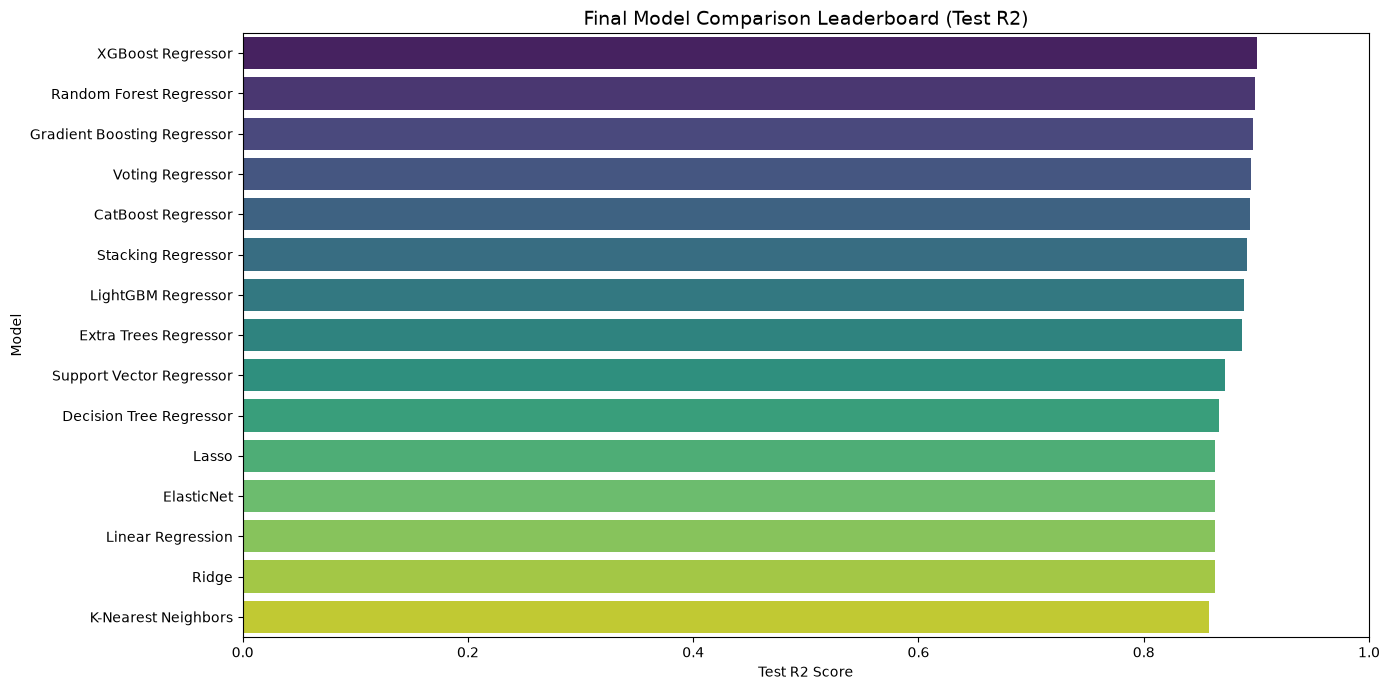

In [466]:
plt.figure(figsize=(14, 7))
sns.barplot(data=leaderboard_df, x='Test R2', y='Model', palette='viridis')
plt.title('Final Model Comparison Leaderboard (Test R2)', fontsize=14)
plt.xlabel('Test R2 Score')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27764\774304528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leaderboard_df, x='Test RMSE', y='Model', palette='rocket')


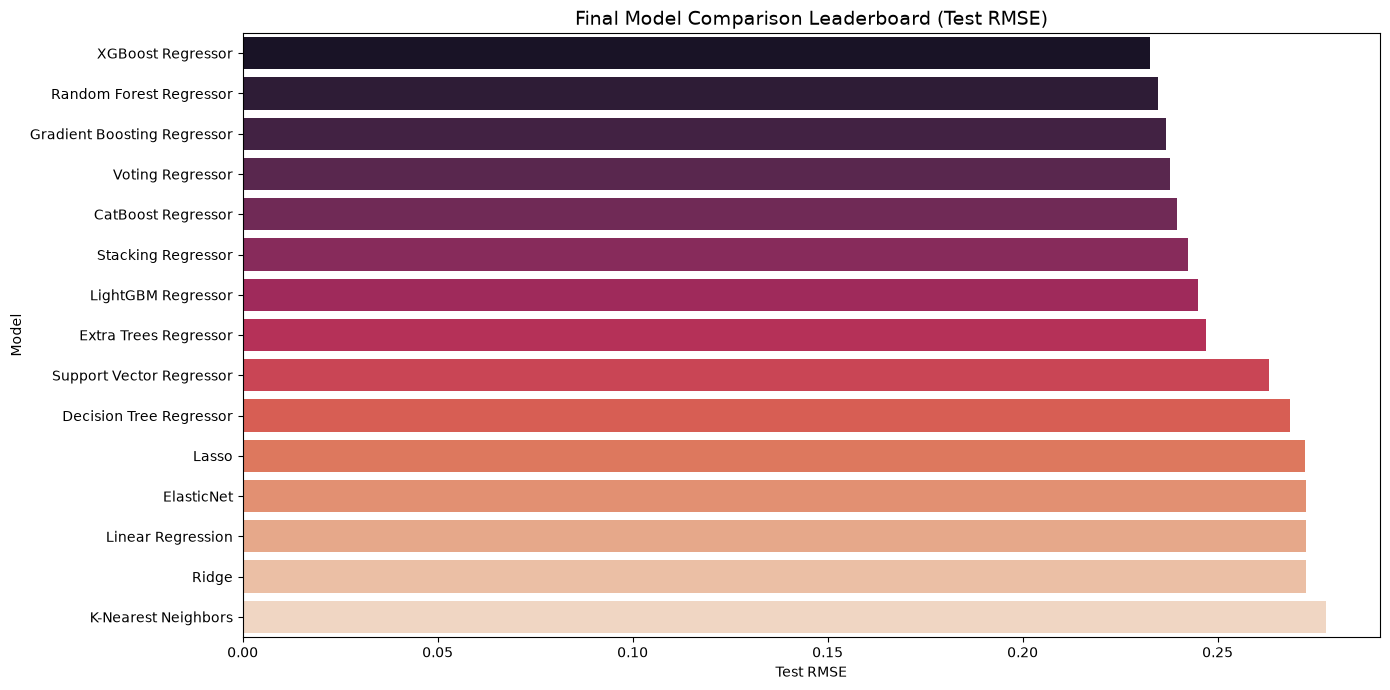

In [467]:
plt.figure(figsize=(14, 7))
sns.barplot(data=leaderboard_df, x='Test RMSE', y='Model', palette='rocket')
plt.title('Final Model Comparison Leaderboard (Test RMSE)', fontsize=14)
plt.xlabel('Test RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()